In [ ]:
import os
import glob
import cv2
import matplotlib.pyplot as plt
import numpy as np

# 1.ĐỌC VÀ LƯU ẢNH VÀO MẢNG

In [ ]:
def load_images_from_folder(img_folder):
    # Các định dạng ảnh hợp lệ cần tìm kiếm
    img_extensions = ['*.png', '*.jpg', '*.jpeg', '*.PNG', '*.JPG']
    
    images = [] # Mảng chứa dữ liệu pixel của ảnh
    labels = [] # Mảng chứa tên loại quả tương ứng

    # 1. Quét tất cả các mục có trong thư mục gốc (vd: thư mục Image)
    for fruit_folder in os.listdir(img_folder):
        fruit_path = os.path.join(img_folder, fruit_folder)
        
        # 2. Đảm bảo mục đang quét là thư mục (để bỏ qua các file rác/ẩn)
        if os.path.isdir(fruit_path):
            
            # 3. Lọc tìm ảnh theo từng đuôi mở rộng (png, jpg,...)
            for ext in img_extensions:
                search_pattern = os.path.join(fruit_path, ext)
                found_files = glob.glob(search_pattern) # Lấy danh sách đường dẫn ảnh
                
                # 4. Đọc từng ảnh và lưu vào mảng
                for file_path in found_files:
                    img = cv2.imread(file_path)
                    img = cv2.resize(img, (400, int(400 * img.shape[0] / img.shape[1])))
                    
                    # Kiểm tra xem ảnh có bị lỗi không trước khi lưu
                    if img is not None:
                        images.append(img)
                        labels.append(fruit_folder) # Dùng tên thư mục con làm nhãn (label)
                        
    return images, labels

Đã tải thành công 34 ảnh.
Các loại trái cây tìm thấy: {'Apple', 'Banana', 'orange'}


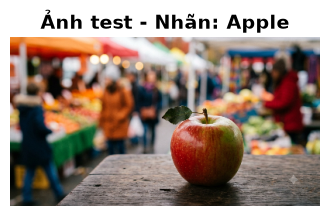

In [ ]:
dataset_folder = '../Img,Video/Image'

images, labels = load_images_from_folder(dataset_folder)

if len(images) > 0:
    print(f"Đã tải thành công {len(images)} ảnh.")
    print(f"Các loại trái cây tìm thấy: {set(labels)}")
    
    # 1. Chọn 1 bức ảnh trong mảng để hiển thị
    sample_img = images[23]
    sample_label = labels[23]
    
    # 2. Chuyển đổi BGR (OpenCV) sang RGB (Matplotlib) để hiển thị màu sắc chuẩn xác
    sample_img_rgb = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)
    
    # 3. Vẽ ảnh ra màn hình Notebook
    plt.figure(figsize=(4, 4))
    plt.imshow(sample_img_rgb)
    plt.title(f"Ảnh test - Nhãn: {sample_label}", fontsize=14, fontweight='bold')
    plt.axis('off') # Tắt trục tọa độ cho đẹp
    plt.show()
    
else:
    print(f"Không tìm thấy ảnh. Kiểm tra lại đường dẫn: {dataset_folder}")

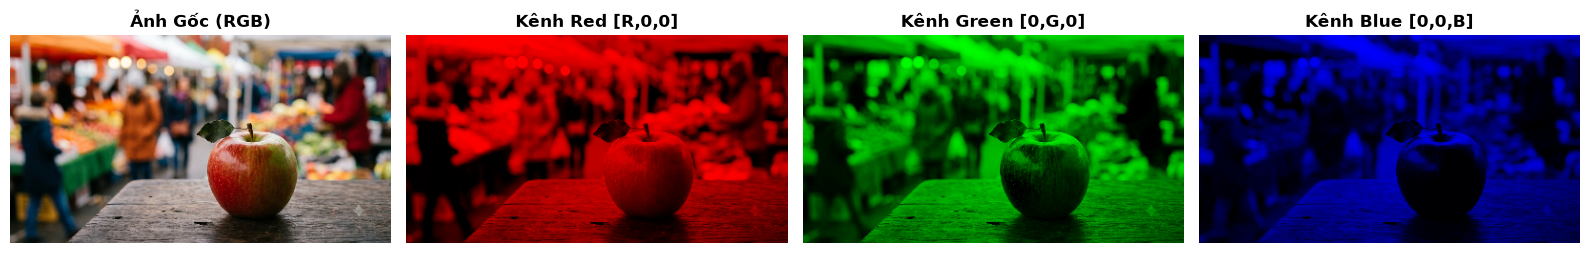

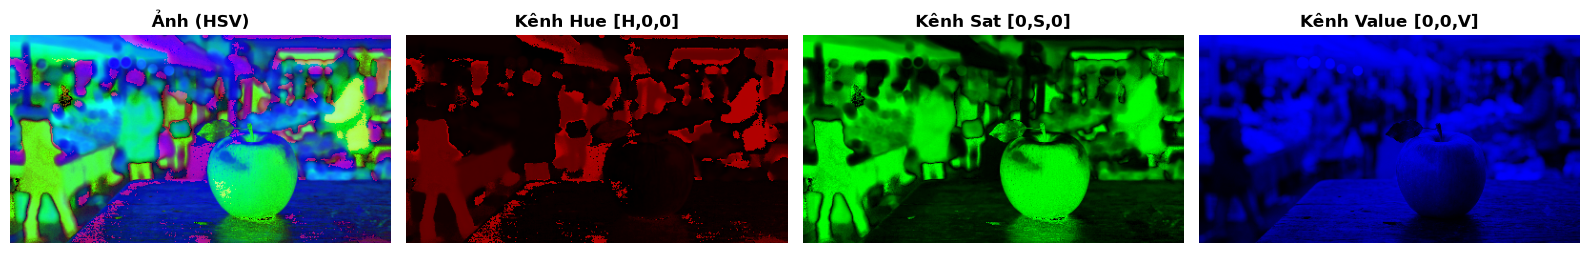

In [ ]:
# ==================== PHẦN 1: TÁCH VÀ HIỂN THỊ CÁC KÊNH RGB ====================
# 1. Chuyển đổi từ BGR (OpenCV) sang RGB
rgb_img = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)

# 2. Tách 3 kênh màu: Red, Green, Blue
r, g, b = cv2.split(rgb_img)

# Tạo một ma trận chứa toàn số 0 có cùng kích thước với 1 kênh màu
zeros = np.zeros_like(r)

# Gộp lại thành ảnh 3 kênh, gán giá trị 0 cho các kênh không mong muốn
img_r = cv2.merge([r, zeros, zeros])     # Ma trận: [R, 0, 0]
img_g = cv2.merge([zeros, g, zeros])     # Ma trận: [0, G, 0]
img_b = cv2.merge([zeros, zeros, b])     # Ma trận: [0, 0, B]

# 3. Hiển thị 1 hàng 4 cột cho hệ RGB
fig, axes_rgb = plt.subplots(1, 4, figsize=(16, 4))

# Ảnh phối màu RGB hoàn chỉnh
axes_rgb[0].imshow(rgb_img)
axes_rgb[0].set_title("Ảnh Gốc (RGB)", fontweight='bold')
axes_rgb[0].axis('off')

# Kênh Red: Giữ nguyên R, các kênh khác bằng 0
axes_rgb[1].imshow(img_r)
axes_rgb[1].set_title("Kênh Red [R,0,0]", fontweight='bold')
axes_rgb[1].axis('off')

# Kênh Green: Giữ nguyên G, các kênh khác bằng 0
axes_rgb[2].imshow(img_g)
axes_rgb[2].set_title("Kênh Green [0,G,0]", fontweight='bold')
axes_rgb[2].axis('off')

# Kênh Blue: Giữ nguyên B, các kênh khác bằng 0
axes_rgb[3].imshow(img_b)
axes_rgb[3].set_title("Kênh Blue [0,0,B]", fontweight='bold')
axes_rgb[3].axis('off')

plt.tight_layout()
plt.show()

# ==================== PHẦN 2: TÁCH VÀ HIỂN THỊ CÁC KÊNH HSV ====================
# 1. Chuyển đổi từ BGR sang HSV
hsv_img = cv2.cvtColor(sample_img, cv2.COLOR_BGR2HSV)

# 2. Tách 3 kênh đặc trưng: Hue, Saturation, Value
h, s, v = cv2.split(hsv_img)

# Gộp lại thành ảnh 3 kênh (giữ nguyên vị trí kênh đang xét, phần còn lại là 0)
img_h = cv2.merge([h, zeros, zeros])     # Ma trận: [H, 0, 0]
img_s = cv2.merge([zeros, s, zeros])     # Ma trận: [0, S, 0]
img_v = cv2.merge([zeros, zeros, v])     # Ma trận: [0, 0, V]

# 3. Hiển thị 1 hàng 4 cột cho hệ HSV
fig, axes_hsv = plt.subplots(1, 4, figsize=(16, 4))

# Hiển thị ảnh HSV làm mốc so sánh
axes_hsv[0].imshow(hsv_img)
axes_hsv[0].set_title("Ảnh (HSV)", fontweight='bold')
axes_hsv[0].axis('off')

# Kênh Hue: Giữ nguyên H
axes_hsv[1].imshow(img_h)
axes_hsv[1].set_title("Kênh Hue [H,0,0]", fontweight='bold')
axes_hsv[1].axis('off')

# Kênh Saturation: Giữ nguyên S
axes_hsv[2].imshow(img_s)
axes_hsv[2].set_title("Kênh Sat [0,S,0]", fontweight='bold')
axes_hsv[2].axis('off')

# Kênh Value: Giữ nguyên V
axes_hsv[3].imshow(img_v)
axes_hsv[3].set_title("Kênh Value [0,0,V]", fontweight='bold')
axes_hsv[3].axis('off')

plt.tight_layout()
plt.show()

# 2.TRÍCH XUẤT ĐẶC TRƯNG TỪ MA TRẬN ẢNH

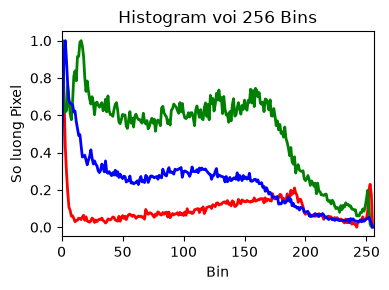

In [ ]:
# Hàm tính toán và vẽ lại Histogram mỗi khi tham số (Bins) thay đổi
def on_trackbar_change(bins_val):
    # Đảm bảo số bins tối thiểu là 1 để tránh lỗi chia cho 0
    bins_val = max(1, bins_val)
    
    # Sử dụng Matplotlib để vẽ biểu đồ cho đẹp và dễ hiển thị cùng ảnh
    fig, ax = plt.subplots(figsize=(4, 3), dpi=100)
    colors = ('r', 'g', 'b') # Tính cho 3 kênh màu RGB
    
    for i, color in enumerate(colors):
        # cv2.calcHist là hàm tối ưu hóa cao của OpenCV để tính histogram
        # Tham số: [ảnh], [kênh_màu], mask, [số_bins], [dải_giá_trị]
        hist = cv2.calcHist([sample_img_rgb], [i], None, [bins_val], [0, 256])
        
        # --- (Tùy chọn) CHUẨN HÓA HISTOGRAM ---
        cv2.normalize(hist, hist, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)
        
        # Vẽ line biểu diễn
        ax.plot(hist, color=color, linewidth=2)
        ax.set_xlim([0, bins_val])
    
    ax.set_title(f"Histogram voi {bins_val} Bins")
    ax.set_xlabel("Bin")
    ax.set_ylabel("So luong Pixel")
    fig.tight_layout()
    

initial_bins = 256
on_trackbar_change(initial_bins)


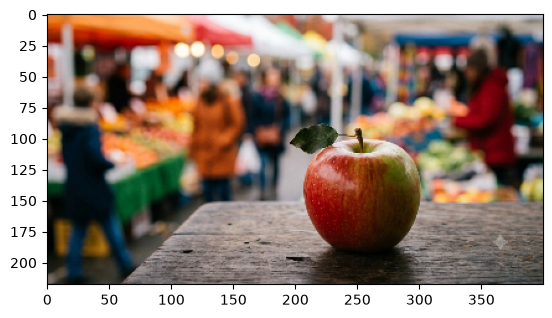

In [ ]:
plt.imshow(sample_img_rgb)

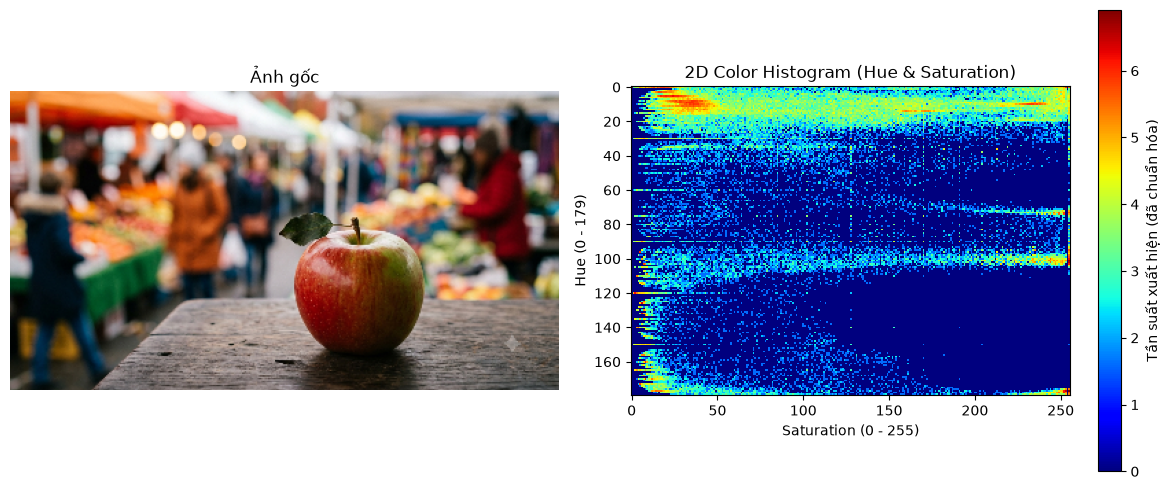

In [ ]:
def hsv_color_histogram(rgb_img,hsv_img):

    # Tham số giải thích:
    # - images: [img_hsv] (truyền vào dưới dạng list)
    # - channels: [0, 1] (chỉ lấy Hue và Saturation)
    # - mask: None (tính trên toàn bộ ảnh)
    # - histSize: [180, 256] (Chia số lượng bin: Hue có 180 bins, Saturation có 256 bins)
    # - ranges: [0, 180, 0, 256] (Khoảng giá trị của H và S)
    hist = cv2.calcHist(
        [hsv_img], 
        channels=[0, 1], 
        mask=None, 
        histSize=[180, 256], 
        ranges=[0, 180, 0, 256]
    )

    # Rất quan trọng: Giúp so sánh các ảnh có kích thước khác nhau (đưa về tỷ lệ 0-1)
    cv2.normalize(hist, hist, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)

    plt.figure(figsize=(12, 5))

    # Ảnh gốc (chuyển sang RGB để hiển thị đúng màu)
    plt.subplot(1, 2, 1)
    plt.imshow(rgb_img)
    plt.title("Ảnh gốc")
    plt.axis("off")

    # Hiển thị 2D Histogram
    plt.subplot(1, 2, 2)
    # Dùng nội suy 'nearest' để hiển thị rõ các ô màu (bins)
    hist_viz = np.log1p(hist * 1000) # Nhân 1000 để khuếch đại sự khác biệt trước khi log

# Hiển thị biến hist_viz thay vì hist
    plt.imshow(hist_viz, interpolation='nearest', cmap='jet')
    plt.title("2D Color Histogram (Hue & Saturation)")
    plt.xlabel("Saturation (0 - 255)")
    plt.ylabel("Hue (0 - 179)")
    plt.colorbar(label="Tần suất xuất hiện (đã chuẩn hóa)")

    plt.tight_layout()
    plt.show()

    # Trả về ma trận histogram đã trải phẳng thành vector 1D
    # (Đây chính là vector đặc trưng - Feature Vector để đưa vào các mô hình ML)
    return hist.flatten()

# --- Chạy thử nghiệm ---
feature_vector = hsv_color_histogram(rgb_img,hsv_img)
# print("Kích thước vector đặc trưng:", feature_vector.shape) # Sẽ là 180 x 256 = 46080 chiều